# 从零搭一个语言模型

代码演示。背景和讲解请看博客 → [oriensx.github.io/blog/minimal-llm](https://oriensx.github.io/blog/minimal-llm)

从上到下依次运行所有 cell，T4 GPU 全程约 4 分钟，CPU 约 10 分钟。建议菜单 → 代码执行程序 → 更改运行时类型 → GPU。

## 0. 环境

In [ ]:
import os, time, urllib.request
import numpy as np
import torch
import torch.nn as nn
from torch.nn import functional as F

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device = {device}")
torch.manual_seed(1337)
if device == "cuda":
    torch.cuda.manual_seed(1337)

## 1. 数据：Tiny Shakespeare（1MB，65 个字符）

In [ ]:
if not os.path.exists("input.txt"):
    url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
    urllib.request.urlretrieve(url, "input.txt")

with open("input.txt", "r", encoding="utf-8") as f:
    text = f.read()

chars = sorted(set(text))
vocab_size = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}
encode = lambda s: [stoi[c] for c in s]
decode = lambda ids: "".join(itos[i] for i in ids)

data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]

print(f"vocab_size = {vocab_size}, train tokens = {len(train_data):,}, val tokens = {len(val_data):,}")
print(f"encode('Hello') = {encode('Hello')}")

## 2. 训练 / 评估 / 生成 工具函数

In [ ]:
def get_batch(split, block_size, batch_size=64):
    src = train_data if split == "train" else val_data
    ix = torch.randint(len(src) - block_size, (batch_size,))
    x = torch.stack([src[i:i + block_size] for i in ix])
    y = torch.stack([src[i + 1:i + block_size + 1] for i in ix])
    return x.to(device), y.to(device)

@torch.no_grad()
def estimate_loss(model, block_size, eval_iters=100):
    model.eval()
    out = {}
    for split in ["train", "val"]:
        ls = torch.zeros(eval_iters)
        for k in range(eval_iters):
            xb, yb = get_batch(split, block_size)
            _, loss = model(xb, yb)
            ls[k] = loss.item()
        out[split] = ls.mean().item()
    model.train()
    return out

def train(model, max_steps, block_size, lr=1e-3, eval_interval=500, label=""):
    model = model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    history = []
    t0 = time.time()
    for step in range(max_steps + 1):
        if step % eval_interval == 0 or step == max_steps:
            ls = estimate_loss(model, block_size)
            history.append((step, ls["train"], ls["val"]))
            print(f"[{label}] step {step:5d} | train {ls['train']:.4f} | val {ls['val']:.4f}")
        xb, yb = get_batch("train", block_size)
        _, loss = model(xb, yb)
        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()
    print(f"[{label}] done in {time.time() - t0:.1f}s")
    return history

def show_sample(model, prompt="", max_new_tokens=200, temperature=1.0):
    ctx = (torch.tensor([encode(prompt)], dtype=torch.long, device=device)
           if prompt else torch.zeros((1, 1), dtype=torch.long, device=device))
    out = model.generate(ctx, max_new_tokens=max_new_tokens, temperature=temperature)
    print(decode(out[0].tolist()))

## 3. Bigram：只看前一个字符

In [ ]:
class BigramModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, vocab_size)

    def forward(self, idx, targets=None):
        logits = self.token_embedding(idx)
        loss = None
        if targets is not None:
            B, T, C = logits.shape
            loss = F.cross_entropy(logits.view(B * T, C), targets.view(B * T))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0):
        for _ in range(max_new_tokens):
            logits, _ = self(idx[:, -1:])
            logits = logits[:, -1, :] / temperature
            probs = F.softmax(logits, dim=-1)
            idx = torch.cat([idx, torch.multinomial(probs, 1)], dim=1)
        return idx

bigram = BigramModel(vocab_size)
bigram_hist = train(bigram, max_steps=5000, block_size=8, label="Bigram")

[Bigram] step     0 | train 4.7305 | val 4.7241
[Bigram] step   500 | train 4.1338 | val 4.1312
[Bigram] step  1000 | train 3.6643 | val 3.6637
[Bigram] step  1500 | train 3.3022 | val 3.3045
[Bigram] step  2000 | train 3.0402 | val 3.0472
[Bigram] step  2500 | train 2.8571 | val 2.8639
[Bigram] step  3000 | train 2.7286 | val 2.7470
[Bigram] step  3500 | train 2.6543 | val 2.6614
[Bigram] step  4000 | train 2.5901 | val 2.6012
[Bigram] step  4500 | train 2.5592 | val 2.5726
[Bigram] step  5000 | train 2.5355 | val 2.5292
[Bigram] done in 19.5s


In [ ]:
show_sample(bigram, max_new_tokens=200)




CExfikRO:
wcowi,STHOLOLETHAR

HAPORThobe d e.
S:gO:33SA:


LTanss:
WanthaiNu qur, vet?
F dXENDoate awice my.

Thstacomzoroup
Yow&$FMOUf isth ble mil;KI ll, ath iree sengmin lat Heriliov ts, anend l 


## 4. MLP：看前 16 个字符

In [ ]:
class MLPModel(nn.Module):
    def __init__(self, vocab_size, context_length=16, n_embd=64, n_hidden=256):
        super().__init__()
        self.context_length = context_length
        self.token_embedding = nn.Embedding(vocab_size, n_embd)
        self.position_embedding = nn.Embedding(context_length, n_embd)
        self.net = nn.Sequential(
            nn.Linear(context_length * n_embd, n_hidden), nn.ReLU(),
            nn.Linear(n_hidden, n_hidden), nn.ReLU(),
            nn.Linear(n_hidden, vocab_size),
        )

    def forward(self, idx, targets=None):
        B, T = idx.shape
        if T < self.context_length:
            pad = torch.zeros(B, self.context_length - T, dtype=torch.long, device=idx.device)
            idx = torch.cat([pad, idx], dim=1)
        elif T > self.context_length:
            idx = idx[:, -self.context_length:]
        T = self.context_length
        tok = self.token_embedding(idx)
        pos = self.position_embedding(torch.arange(T, device=idx.device))
        x = (tok + pos).reshape(B, -1)
        logits = self.net(x).unsqueeze(1)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.squeeze(1), targets[:, -1])
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0):
        for _ in range(max_new_tokens):
            logits, _ = self(idx[:, -self.context_length:])
            logits = logits[:, -1, :] / temperature
            probs = F.softmax(logits, dim=-1)
            idx = torch.cat([idx, torch.multinomial(probs, 1)], dim=1)
        return idx

mlp = MLPModel(vocab_size, context_length=16)
print(f"MLP 参数量: {sum(p.numel() for p in mlp.parameters()):,}")
mlp_hist = train(mlp, max_steps=10000, block_size=16, eval_interval=1000, label="MLP")

MLP 参数量: 350,081
[MLP] step     0 | train 4.1955 | val 4.1901
[MLP] step  1000 | train 2.2898 | val 2.3369
[MLP] step  2000 | train 2.1023 | val 2.1772
[MLP] step  3000 | train 1.9814 | val 2.0809
[MLP] step  4000 | train 1.8881 | val 2.0606
[MLP] step  5000 | train 1.8667 | val 1.9851
[MLP] step  6000 | train 1.8479 | val 2.0112
[MLP] step  7000 | train 1.8138 | val 1.9691
[MLP] step  8000 | train 1.7573 | val 1.9850
[MLP] step  9000 | train 1.7320 | val 1.9565
[MLP] step 10000 | train 1.7817 | val 1.8724
[MLP] done in 44.5s


In [ ]:
show_sample(mlp, max_new_tokens=300)


EELLO:::
Now!
Tliring pear.
Hish wonching: thy haight, why.
Hushoul knamoperen'd gonop
Is worl to killoy,--
A dud Ceriard to them sut Edwing in he pool

AUFI'W:
The wome, rurt for treagh tomef's teaks exongs,
Mades of my of.

HENRY BOLINGBROKE:
Sadspe your graced uphense asail no vell sme from carcy


## 5. MiniGPT：Self-Attention

$$ \text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{Q K^\top}{\sqrt{d_k}}\right) V $$

In [ ]:
class SelfAttention(nn.Module):
    def __init__(self, n_embd, head_size, context_length, dropout=0.1):
        super().__init__()
        self.head_size = head_size
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.key   = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer("mask", torch.tril(torch.ones(context_length, context_length)))

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.query(x), self.key(x), self.value(x)
        att = q @ k.transpose(-2, -1) * (self.head_size ** -0.5)
        att = att.masked_fill(self.mask[:T, :T] == 0, float("-inf"))
        att = self.dropout(F.softmax(att, dim=-1))
        return att @ v

class MultiHeadAttention(nn.Module):
    def __init__(self, n_embd, n_head, context_length, dropout=0.1):
        super().__init__()
        head_size = n_embd // n_head
        self.heads = nn.ModuleList([
            SelfAttention(n_embd, head_size, context_length, dropout) for _ in range(n_head)
        ])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.dropout(self.proj(torch.cat([h(x) for h in self.heads], dim=-1)))

class FeedForward(nn.Module):
    def __init__(self, n_embd, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd), nn.GELU(),
            nn.Linear(4 * n_embd, n_embd), nn.Dropout(dropout),
        )
    def forward(self, x):
        return self.net(x)

class TransformerBlock(nn.Module):
    def __init__(self, n_embd, n_head, context_length, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(n_embd)
        self.attn = MultiHeadAttention(n_embd, n_head, context_length, dropout)
        self.ln2 = nn.LayerNorm(n_embd)
        self.ffn = FeedForward(n_embd, dropout)
    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ffn(self.ln2(x))
        return x

class MiniGPT(nn.Module):
    def __init__(self, vocab_size, context_length=64, n_embd=128, n_head=4, n_layer=2, dropout=0.1):
        super().__init__()
        self.context_length = context_length
        self.token_embedding = nn.Embedding(vocab_size, n_embd)
        self.position_embedding = nn.Embedding(context_length, n_embd)
        self.blocks = nn.Sequential(*[
            TransformerBlock(n_embd, n_head, context_length, dropout) for _ in range(n_layer)
        ])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        if T > self.context_length:
            idx = idx[:, -self.context_length:]
            if targets is not None:
                targets = targets[:, -self.context_length:]
            T = self.context_length
        x = self.token_embedding(idx) + self.position_embedding(torch.arange(T, device=idx.device))
        x = self.ln_f(self.blocks(x))
        logits = self.lm_head(x)
        loss = None
        if targets is not None:
            B, T, C = logits.shape
            loss = F.cross_entropy(logits.view(B * T, C), targets.view(B * T))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        for _ in range(max_new_tokens):
            logits, _ = self(idx[:, -self.context_length:])
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = float("-inf")
            probs = F.softmax(logits, dim=-1)
            idx = torch.cat([idx, torch.multinomial(probs, 1)], dim=1)
        return idx

minigpt = MiniGPT(vocab_size, context_length=64, n_embd=128, n_head=4, n_layer=2)
print(f"MiniGPT 参数量: {sum(p.numel() for p in minigpt.parameters()):,}")
minigpt_hist = train(minigpt, max_steps=10000, block_size=64, eval_interval=1000, label="MiniGPT")

In [ ]:
show_sample(minigpt, prompt="KING RICHARD:\n", max_new_tokens=400, temperature=0.8)

KING RICHARD:
Lock? if God present me to actory and cull have no come.

FLORIZEL:
And somethinks oft be him in the hand side
Upon to the mantlementryments be you happy:
I pray you, what is Clarence, let it are you,
Why, force me with the troubley to man.
I were ye secret well pray to think deperd again,
And in the marry and that instant or of the bastake. More not hie hence:
I am all be so servant it us you.

D


## 6. Loss 曲线对比

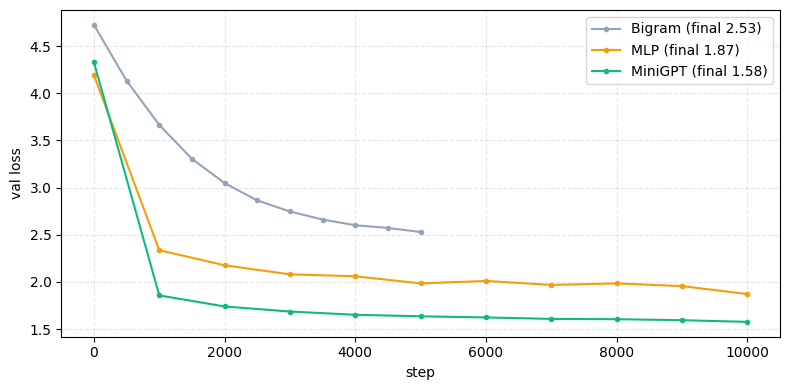

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
for hist, label, color in [
    (bigram_hist,  "Bigram",  "#94a3b8"),
    (mlp_hist,     "MLP",     "#f59e0b"),
    (minigpt_hist, "MiniGPT", "#10b981"),
]:
    steps = [h[0] for h in hist]
    val_losses = [h[2] for h in hist]
    ax.plot(steps, val_losses, marker="o", markersize=3, linewidth=1.5,
            color=color, label=f"{label} (final {val_losses[-1]:.2f})")
ax.set_xlabel("step")
ax.set_ylabel("val loss")
ax.legend()
ax.grid(True, alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

## 7. 自己玩

In [ ]:
show_sample(minigpt, prompt="ROMEO:\n", max_new_tokens=500, temperature=0.8)